# Random Forest Classification – Glass Dataset

The assignment requires:
1. Exploratory Data Analysis (EDA)
2. Data visualization
3. Data preprocessing
4. Random Forest implementation
5. Evaluation using accuracy, precision, recall and F1-score
6. Bagging and Boosting comparison
7. Explanation of Bagging vs Boosting
8. Explanation of handling imbalanced data

The target variable is **`Type`**, while the other nine columns are the glass measurements.

**Important:** The supplied dataset does not contain categorical predictor variables. All nine predictors are numerical, so categorical encoding is not required.


## 1. Import Libraries and Load the Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load the supplied workbook
description = pd.read_excel("/content/glass.xlsx", sheet_name="Description", header=None)
df = pd.read_excel("/content/glass.xlsx", sheet_name="glass")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 2. Dataset Description

The workbook's Description sheet identifies the variables as:

- **RI** – refractive index
- **Na** – Sodium
- **Mg** – Magnesium
- **Al** – Aluminum
- **Si** – Silicon
- **K** – Potassium
- **Ca** – Calcium
- **Ba** – Barium
- **Fe** – Iron
- **Type** – glass classification target
.


In [3]:
print("Data types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
display(df.describe().T)


Data types:


,Data Type
RI,float64
Na,float64
Mg,float64
Al,float64
Si,float64
K,float64
Ca,float64
Ba,float64
Fe,float64
Type,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
RI,214.0,1.518365,0.003037,1.51115,1.516522,1.51768,1.519157,1.53393
Na,214.0,13.407850,0.816604,10.73000,12.907500,13.30000,13.825000,17.38000
Mg,214.0,2.684533,1.442408,0.00000,2.115000,3.48000,3.600000,4.49000
Al,214.0,1.444907,0.499270,0.29000,1.190000,1.36000,1.630000,3.50000
Si,214.0,72.650935,0.774546,69.81000,72.280000,72.79000,73.087500,75.41000
K,214.0,0.497056,0.652192,0.00000,0.122500,0.55500,0.610000,6.21000
Ca,214.0,8.956963,1.423153,5.43000,8.240000,8.60000,9.172500,16.19000
Ba,214.0,0.175047,0.497219,0.00000,0.000000,0.00000,0.000000,3.15000
Fe,214.0,0.057009,0.097439,0.00000,0.000000,0.00000,0.100000,0.51000
Type,214.0,2.780374,2.103739,1.00000,1.000000,2.00000,3.000000,7.00000


## 3. Exploratory Data Analysis – Missing Values, Duplicates and Inconsistencies

First, I check whether the dataset contains missing values or duplicate rows.

There are no missing values in the supplied `glass` sheet. Since all predictor columns are numeric, no categorical encoding is needed.
and i also inspect the unique target values and basic ranges to identify obvious data-entry issues.


In [4]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

display(missing)

print("Duplicate rows:", df.duplicated().sum())

print("\nTarget classes:")
print(sorted(df["Type"].unique()))

print("\nTarget counts:")
display(df["Type"].value_counts().sort_index().to_frame("Count"))

print("\nMinimum and maximum values:")
display(df.min().to_frame("Minimum").join(df.max().to_frame("Maximum")))


,Missing Count,Missing Percentage
RI,0,0.0
Na,0,0.0
Mg,0,0.0
Al,0,0.0
Si,0,0.0
K,0,0.0
Ca,0,0.0
Ba,0,0.0
Fe,0,0.0
Type,0,0.0


Duplicate rows: 1

Target classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7)]

Target counts:


,Count
Type,
1,70
2,76
3,17
5,13
6,9
7,29



Minimum and maximum values:


,Minimum,Maximum
RI,1.51115,1.53393
Na,10.73000,17.38000
Mg,0.00000,4.49000
Al,0.29000,3.50000
Si,69.81000,75.41000
K,0.00000,6.21000
Ca,5.43000,16.19000
Ba,0.00000,3.15000
Fe,0.00000,0.51000
Type,1.00000,7.00000


### Observation

The supplied data contains no missing values, so imputation is not necessary for the final dataset. I still include an imputation step in the modelling pipeline as a defensive preprocessing step; because there are currently no missing observations, it does not alter the data.

There are no categorical predictor variables, so one-hot encoding is not required.

For Random Forest, feature scaling is **not required for the tree-based model itself**. However, because the assignment explicitly asks for a scaling technique, I demonstrate standardization and explain that it is not essential for Random Forest performance. The scaled data can also be used consistently when comparing with other models.


## 4. Outlier Analysis

I use the IQR rule to flag potential outliers:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR


In [5]:
feature_cols = [c for c in df.columns if c != "Type"]

outlier_summary = []

for col in feature_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": count,
        "Percentage": round(count / len(df) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)
display(outlier_table)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Percentage
0,RI,1.516522,1.519157,0.002635,1.51257,1.52311,17,7.94
1,Na,12.907500,13.825000,0.917500,11.53125,15.20125,7,3.27
2,Mg,2.115000,3.600000,1.485000,-0.11250,5.82750,0,0.00
3,Al,1.190000,1.630000,0.440000,0.53000,2.29000,18,8.41
4,Si,72.280000,73.087500,0.807500,71.06875,74.29875,12,5.61
5,K,0.122500,0.610000,0.487500,-0.60875,1.34125,7,3.27
6,Ca,8.240000,9.172500,0.932500,6.84125,10.57125,26,12.15
7,Ba,0.000000,0.000000,0.000000,0.00000,0.00000,38,17.76
8,Fe,0.000000,0.100000,0.100000,-0.15000,0.25000,12,5.61


## 5. Class Imbalance Check

The target classes are not equally represented. This matters because a classifier can achieve a reasonable overall accuracy while performing poorly on a minority class.

I therefore:
- display the class counts and percentages,
- use a **stratified train/test split**,
- report weighted metrics,
- and additionally inspect the class-specific classification report.

For the Random Forest model, I also test class_weight=balanced during tuning so that minority classes can receive greater importance during training.


,Count,Percentage
Type,,
1,70,32.71
2,76,35.51
3,17,7.94
5,13,6.07
6,9,4.21
7,29,13.55


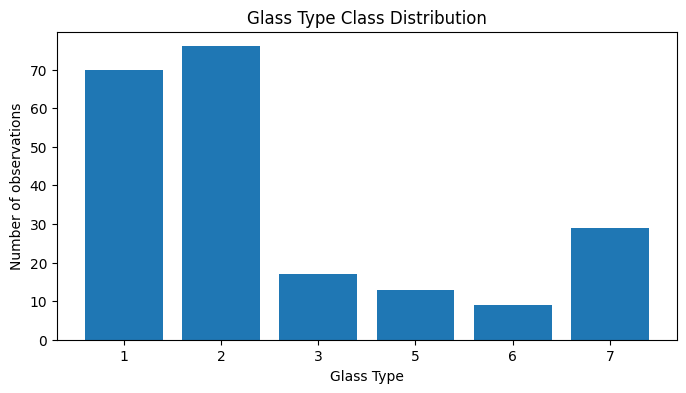

In [6]:
class_counts = df["Type"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage": (class_counts / len(df) * 100).round(2)
})

display(class_distribution)

plt.figure(figsize=(8,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Glass Type Class Distribution")
plt.xlabel("Glass Type")
plt.ylabel("Number of observations")
plt.show()


## 6. Data Visualization – Histograms

Histograms are used to understand the distributions of the nine numerical predictors.


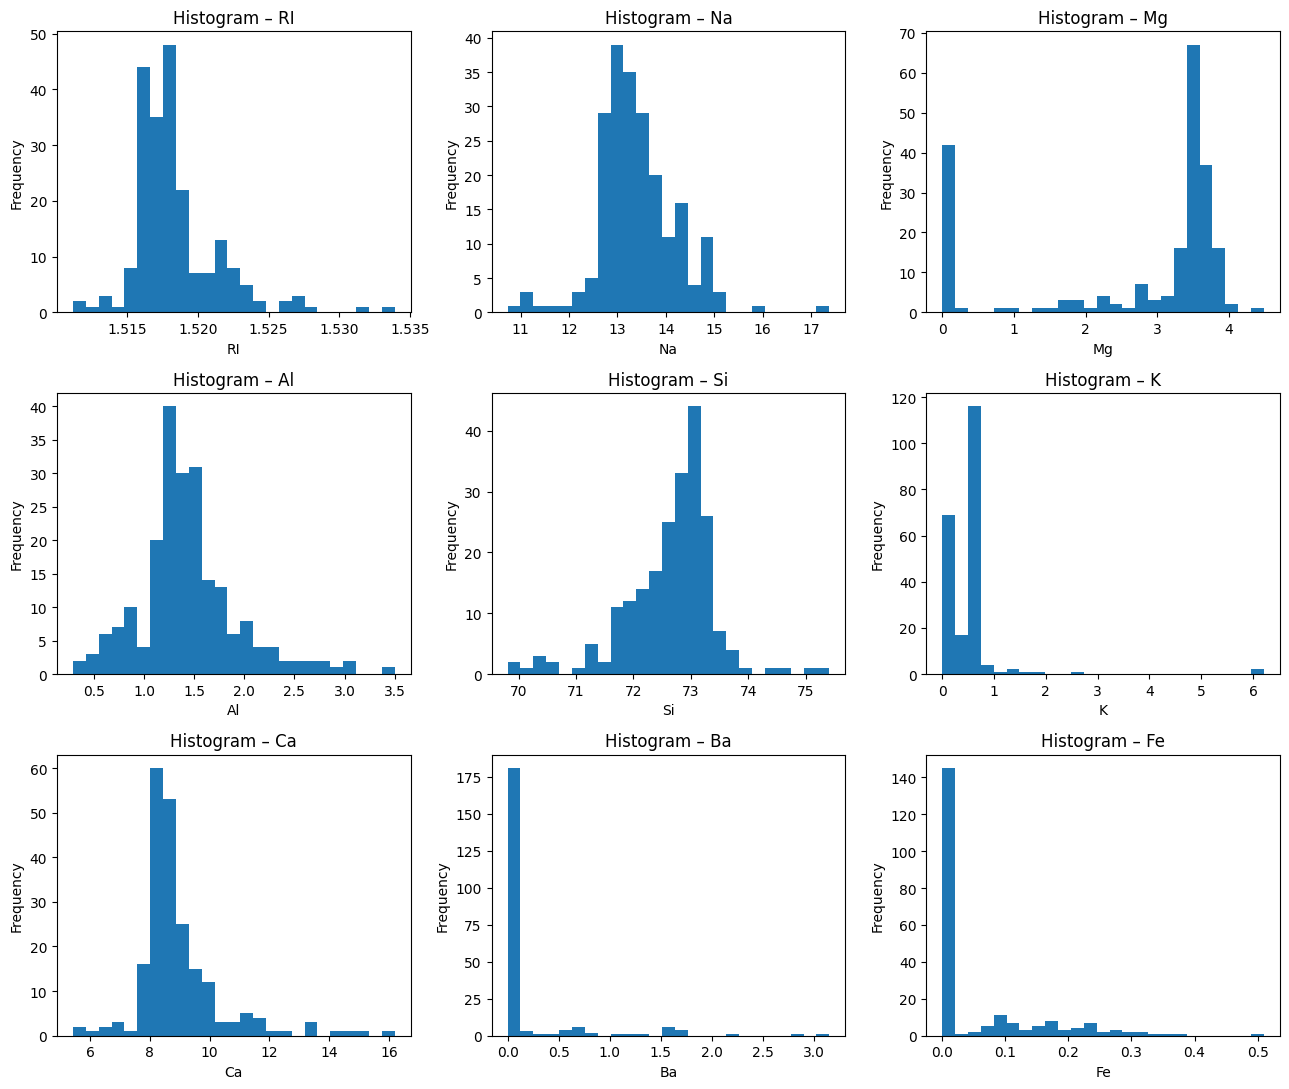

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    ax.hist(df[col], bins=25)
    ax.set_title(f"Histogram – {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


## 7. Box Plots

Box plots make the spread and potential extreme observations easier to compare across features.


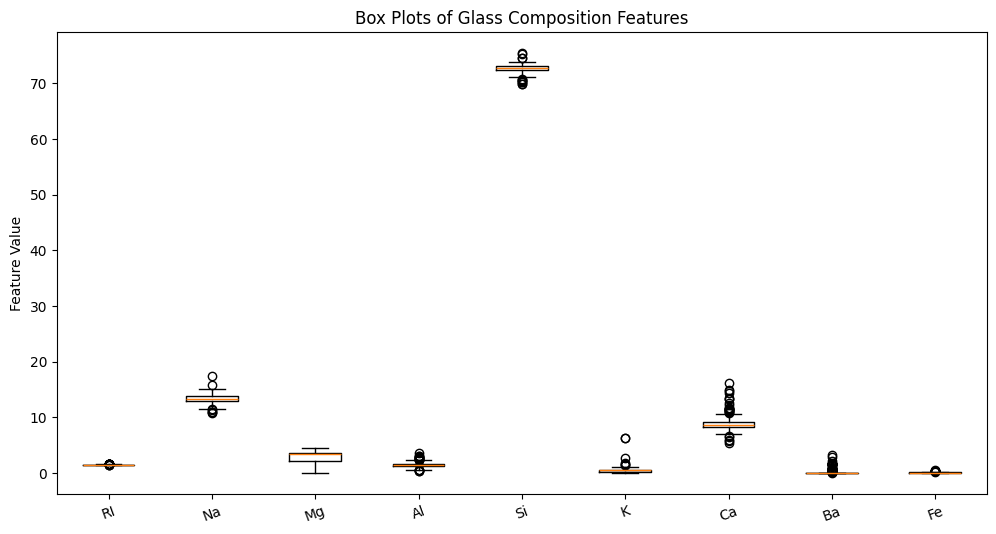

In [8]:
plt.figure(figsize=(12, 6))
plt.boxplot(
    [df[col] for col in feature_cols],
    labels=feature_cols
)
plt.title("Box Plots of Glass Composition Features")
plt.ylabel("Feature Value")
plt.xticks(rotation=20)
plt.show()


## 8. Correlation Analysis

Correlation helps identify linear relationships between numerical variables.

A high correlation between two predictors does not automatically mean one should be removed. Random Forest can handle correlated predictors, although correlated variables can distribute importance across several features.


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
RI,1.000,-0.192,-0.122,-0.407,-0.542,-0.290,0.810,-0.000,0.143
Na,-0.192,1.000,-0.274,0.157,-0.070,-0.266,-0.275,0.327,-0.241
Mg,-0.122,-0.274,1.000,-0.482,-0.166,0.005,-0.444,-0.492,0.083
Al,-0.407,0.157,-0.482,1.000,-0.006,0.326,-0.260,0.479,-0.074
Si,-0.542,-0.070,-0.166,-0.006,1.000,-0.193,-0.209,-0.102,-0.094
K,-0.290,-0.266,0.005,0.326,-0.193,1.000,-0.318,-0.043,-0.008
Ca,0.810,-0.275,-0.444,-0.260,-0.209,-0.318,1.000,-0.113,0.125
Ba,-0.000,0.327,-0.492,0.479,-0.102,-0.043,-0.113,1.000,-0.059
Fe,0.143,-0.241,0.083,-0.074,-0.094,-0.008,0.125,-0.059,1.000


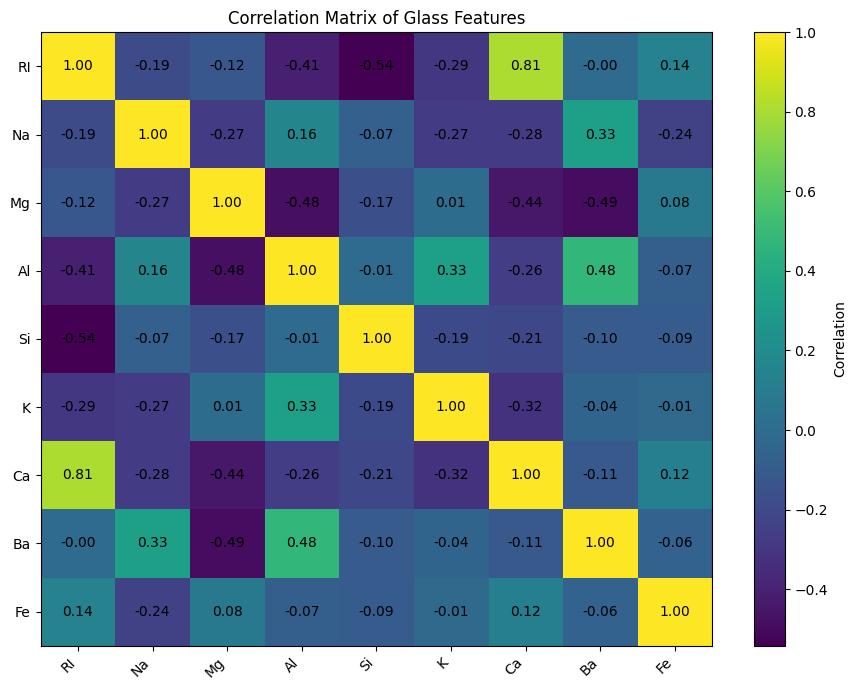

In [9]:
corr = df[feature_cols].corr()

display(corr.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of Glass Features")
plt.tight_layout()
plt.show()


## 9. Pairwise Relationships

The dataset has only nine predictors, so a scatter-matrix is useful for visually checking relationships among a sample of observations.

The target class is not directly used as a numerical variable in this plot because the target labels are categorical classes rather than continuous measurements.


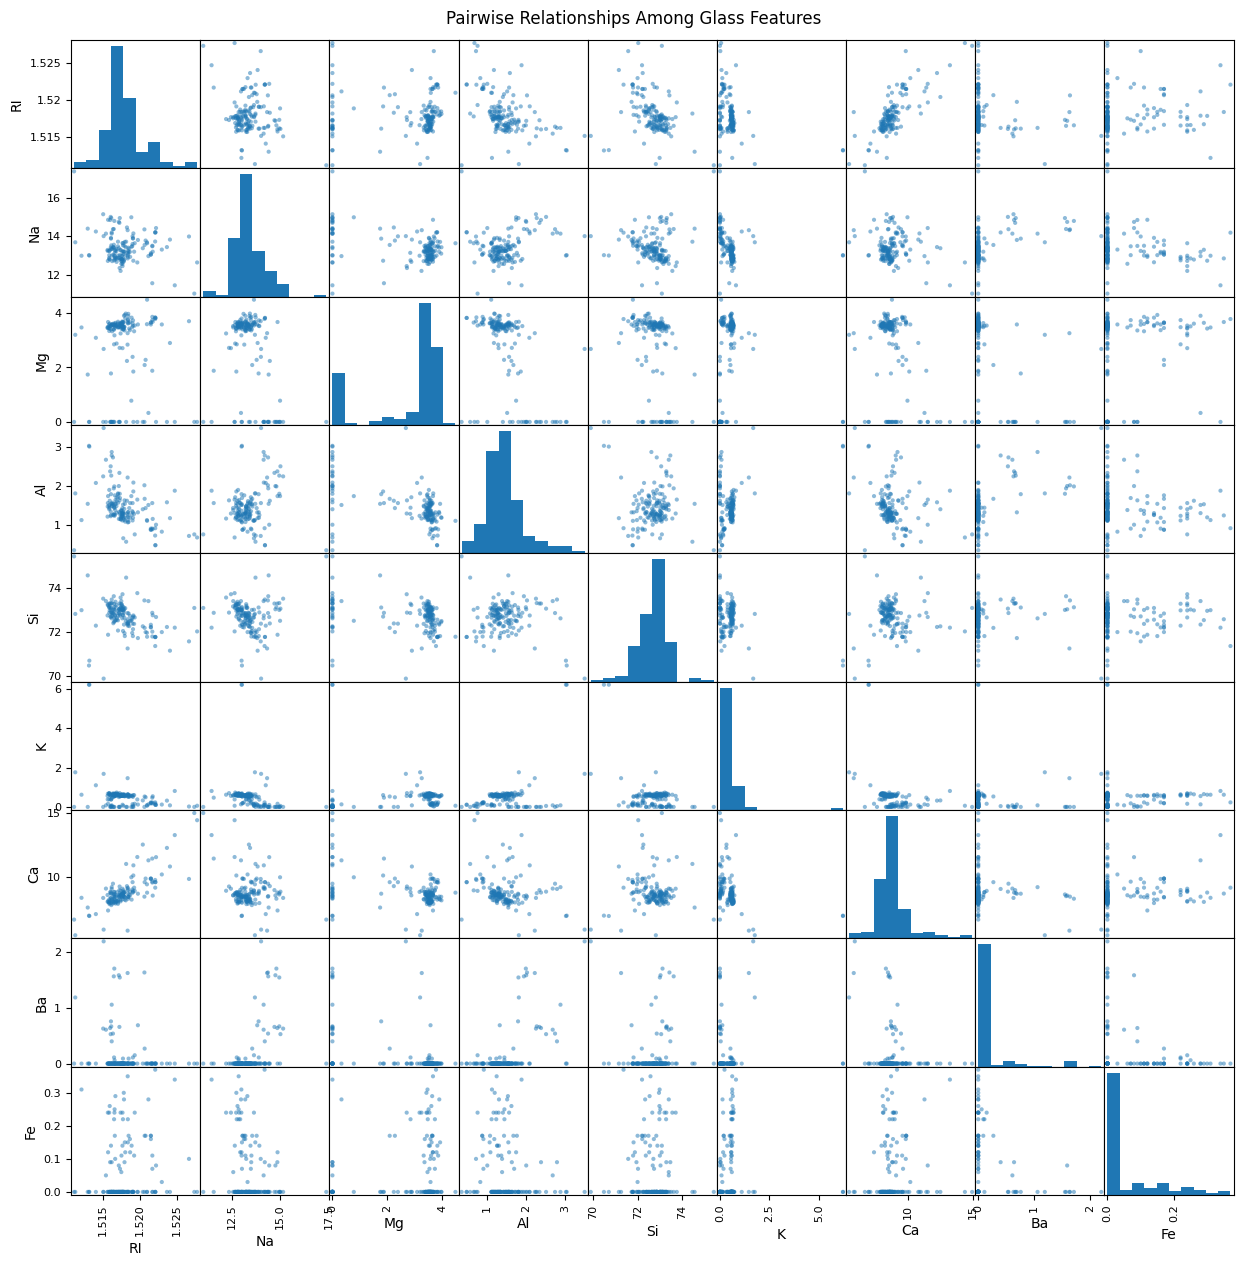

In [10]:
sample = df.sample(min(150, len(df)), random_state=42)

pd.plotting.scatter_matrix(
    sample[feature_cols],
    figsize=(15, 15),
    diagonal="hist",
    alpha=0.5
)
plt.suptitle("Pairwise Relationships Among Glass Features", y=0.90)
plt.show()


## 10. Data Preprocessing

### Missing values
There are no missing values in the supplied data. The pipeline nevertheless contains a median imputer so that the modelling workflow remains robust if missing values are introduced later.

### Categorical variables
There are no categorical predictor variables in the supplied dataset. Therefore, one-hot encoding is not required.

### Feature scaling
Random Forest is a tree-based algorithm and does not depend on distances, so scaling is not required for the Random Forest itself. Nevertheless, the assignment asks for scaling, so I show standardization as part of the preprocessing discussion.

For the final Random Forest pipeline, I intentionally **do not scale the tree inputs**, because it would not improve the tree's split decisions. This is an important modelling choice rather than an omission.

### Imbalance
I use stratification and compare normal Random Forest with a `class_weight="balanced"` version during hyperparameter tuning.


In [11]:
X = df[feature_cols].copy()
y = df["Type"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training shape: (171, 9)
Testing shape: (43, 9)

Training class proportions:
Type
1    0.327
2    0.357
3    0.082
5    0.058
6    0.041
7    0.135
Name: proportion, dtype: float64

Testing class proportions:
Type
1    0.326
2    0.349
3    0.070
5    0.070
6    0.047
7    0.140
Name: proportion, dtype: float64


## 11. Standardization Demonstration

Standardization converts a numerical variable to approximately:

**z = (x − mean) / standard deviation**

This puts variables on a comparable scale.

For this Random Forest assignment, scaling is demonstrated here but is not necessary for the final tree model. The reason is that tree split decisions are based on threshold comparisons and are unaffected by a linear change of scale.


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_preview = pd.DataFrame(
    X_train_scaled[:5],
    columns=feature_cols
)

display(scaled_preview)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,-0.642975,-1.705978,-1.941220,-0.501138,3.215401,3.989840,-0.020071,-0.344535,-0.619243
1,1.182333,1.002367,0.766828,-1.979694,-1.104123,-0.684057,0.448282,-0.344535,-0.619243
2,-0.268135,-0.867111,0.582511,-0.275248,0.555284,0.218240,-0.195703,-0.344535,0.739572
3,1.214928,-0.196016,0.731383,-1.322558,-0.825444,-0.647965,0.777593,-0.344535,-0.619243
4,-0.007377,0.319288,0.802274,-0.336854,-0.863446,0.091918,-0.466470,-0.344535,2.486620


## 12. Random Forest Model Implementation

A Random Forest is an ensemble of Decision Trees.

Each tree is trained on a bootstrap sample and considers a random subset of features when finding splits. The final classification is based on the combined predictions of the trees.

I start with a baseline Random Forest and evaluate it on the held-out test set.


In [13]:
rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision (weighted)": precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    "Recall (weighted)": recall_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    "F1 Score (weighted)": f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
}

display(pd.DataFrame([rf_metrics]).round(4))

print("Classification report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,Random Forest,0.814,0.8283,0.814,0.8135


Classification report:
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.79      0.73      0.76        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.81        43
   macro avg       0.87      0.82      0.83        43
weighted avg       0.83      0.81      0.81        43



## 13. Random Forest Confusion Matrix

,Predicted 1,Predicted 2,Predicted 3,Predicted 5,Predicted 6,Predicted 7
Actual 1,12,2,0,0,0,0
Actual 2,3,11,0,0,1,0
Actual 3,1,0,2,0,0,0
Actual 5,0,1,0,2,0,0
Actual 6,0,0,0,0,2,0
Actual 7,0,0,0,0,0,6


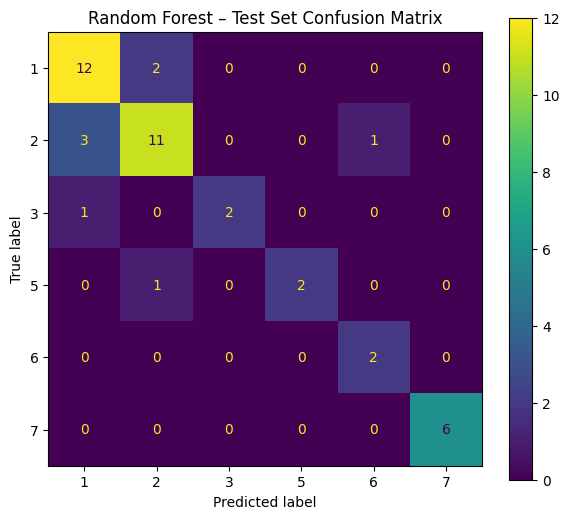

In [14]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=sorted(y.unique()))

display(pd.DataFrame(
    cm_rf,
    index=[f"Actual {c}" for c in sorted(y.unique())],
    columns=[f"Predicted {c}" for c in sorted(y.unique())]
))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=sorted(y.unique())
).plot(values_format="d", ax=ax)
plt.title("Random Forest – Test Set Confusion Matrix")
plt.show()


## 14. Random Forest Feature Importance

Feature importance gives an indication of which predictors contributed most to reducing impurity across the forest.

It should be interpreted as model-based importance, not as proof that a feature causes a particular glass type.


,Importance
Mg,0.165070
Al,0.159391
Ca,0.133504
RI,0.132811
Na,0.111128
Si,0.090681
K,0.087130
Ba,0.080941
Fe,0.039345


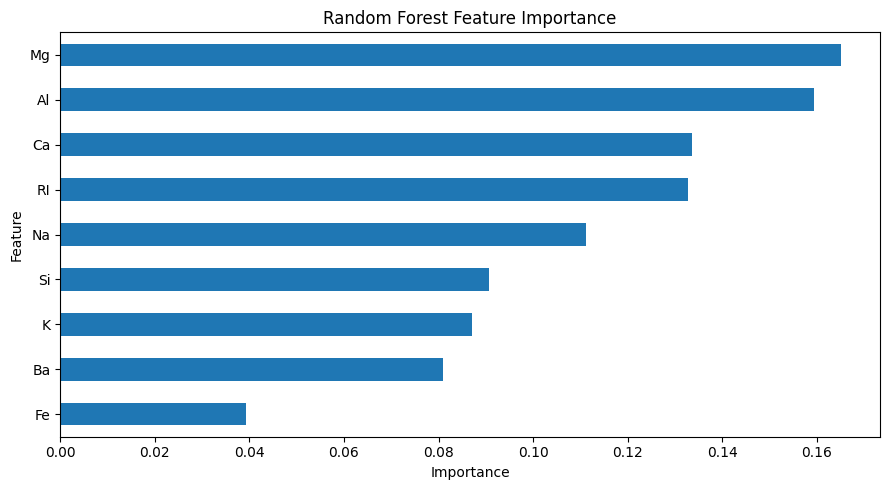

In [15]:
rf_model = rf_pipeline.named_steps["model"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

display(importance.to_frame("Importance"))

plt.figure(figsize=(9, 5))
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 15. Hyperparameter Tuning and Imbalance Handling

The main parameters tested are:
- `n_estimators` – number of trees
- `max_depth` – maximum depth of each tree
- `min_samples_split` – minimum observations needed to split a node
- `min_samples_leaf` – minimum observations in a leaf
- `max_features` – number of candidate features considered at each split
- `class_weight` – whether to give extra weight to minority classes

I use **weighted F1-score** for model selection because the target classes are imbalanced.


In [17]:
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

grid_rf.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(grid_rf.best_params_)

print("\nBest cross-validation weighted F1-score:",
      round(grid_rf.best_score_, 4))


Best Random Forest parameters:
{'model__class_weight': None, 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation weighted F1-score: 0.776


## 16. Tuned Random Forest Evaluation

In [18]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)

tuned_rf_metrics = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision (weighted)": precision_score(y_test, y_pred_best_rf, average="weighted", zero_division=0),
    "Recall (weighted)": recall_score(y_test, y_pred_best_rf, average="weighted", zero_division=0),
    "F1 Score (weighted)": f1_score(y_test, y_pred_best_rf, average="weighted", zero_division=0)
}

display(pd.DataFrame([tuned_rf_metrics]).round(4))

print("Classification report:")
print(classification_report(y_test, y_pred_best_rf, zero_division=0))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,Tuned Random Forest,0.8372,0.8542,0.8372,0.8355


Classification report:
              precision    recall  f1-score   support

           1       0.76      0.93      0.84        14
           2       0.85      0.73      0.79        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.84        43
   macro avg       0.88      0.83      0.84        43
weighted avg       0.85      0.84      0.84        43



## 17. Bagging Method

### What is Bagging?

**Bagging (Bootstrap Aggregating)** trains multiple models independently on different bootstrap samples of the training data. Their predictions are then aggregated.

Random Forest itself is an advanced tree-based bagging method because it combines bootstrap sampling with random feature selection.

For a direct comparison, I also implement a separate `BaggingClassifier` using Decision Trees as the base estimators.


In [21]:
from sklearn.tree import DecisionTreeClassifier

bagging = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=300,
        max_samples=0.8,
        max_features=0.8,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)

bagging_metrics = {
    "Model": "Bagging – Decision Trees",
    "Accuracy": accuracy_score(y_test, y_pred_bag),
    "Precision (weighted)": precision_score(y_test, y_pred_bag, average="weighted", zero_division=0),
    "Recall (weighted)": recall_score(y_test, y_pred_bag, average="weighted", zero_division=0),
    "F1 Score (weighted)": f1_score(y_test, y_pred_bag, average="weighted", zero_division=0)
}

display(pd.DataFrame([bagging_metrics]).round(4))

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,Bagging – Decision Trees,0.7907,0.8018,0.7907,0.7872


## 18. Boosting Methods

### What is Boosting?

Boosting builds models **sequentially**. Each new model focuses more attention on observations that previous models handled poorly.

Unlike bagging, where models are mainly trained independently and then aggregated, boosting creates a sequence where later learners depend on the earlier learners' performance.

I use two common boosting methods:
- **AdaBoost**
- **Gradient Boosting**

These are included so the assignment's request to apply and compare boosting methods is covered.


In [22]:
adaboost = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ))
])

gradient_boosting = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

adaboost.fit(X_train, y_train)
gradient_boosting.fit(X_train, y_train)

y_pred_ada = adaboost.predict(X_test)
y_pred_gb = gradient_boosting.predict(X_test)

def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (weighted)": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Score (weighted)": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

boosting_results = pd.DataFrame([
    get_metrics("AdaBoost", y_test, y_pred_ada),
    get_metrics("Gradient Boosting", y_test, y_pred_gb)
])

display(boosting_results.round(4))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,AdaBoost,0.4884,0.5038,0.4884,0.4830
1,Gradient Boosting,0.7674,0.7682,0.7674,0.7648


## 19. Bagging vs Boosting – Final Comparison

The comparison includes:
- Random Forest
- Tuned Random Forest
- Bagging with Decision Trees
- AdaBoost
- Gradient Boosting

The values below are generated from the held-out test set. The best model should be selected by considering the requested metrics rather than accuracy alone.


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted)
0,Random Forest,0.8140,0.8283,0.8140,0.8135
1,Tuned Random Forest,0.8372,0.8542,0.8372,0.8355
2,Bagging – Decision Trees,0.7907,0.8018,0.7907,0.7872
3,AdaBoost,0.4884,0.5038,0.4884,0.4830
4,Gradient Boosting,0.7674,0.7682,0.7674,0.7648


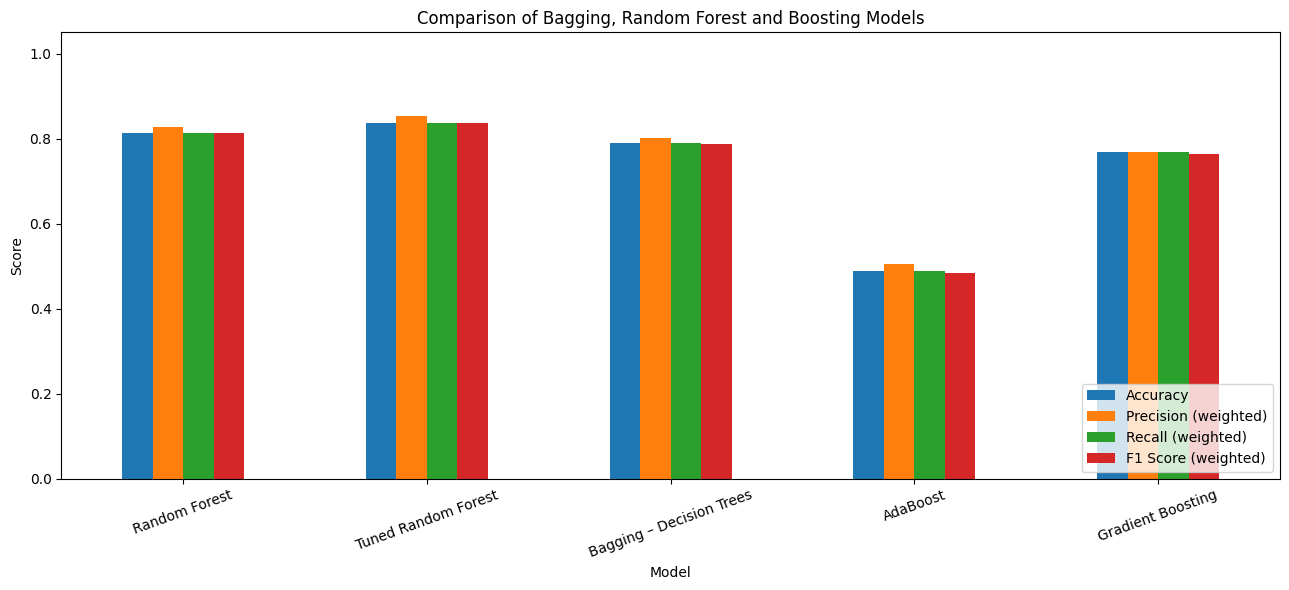

In [23]:
all_results = pd.DataFrame([
    rf_metrics,
    tuned_rf_metrics,
    bagging_metrics,
    get_metrics("AdaBoost", y_test, y_pred_ada),
    get_metrics("Gradient Boosting", y_test, y_pred_gb)
])

display(all_results.round(4))

all_results.set_index("Model").plot(
    kind="bar",
    figsize=(13, 6),
    ylim=(0, 1.05)
)

plt.title("Comparison of Bagging, Random Forest and Boosting Models")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# 20. Bagging vs Boosting – Explanation

## Bagging

Bagging means **Bootstrap Aggregating**.

The basic process is:

1. Create multiple bootstrap samples from the training data.
2. Train a separate model on each sample.
3. Train the models mostly independently.
4. Combine their predictions by voting or averaging.

### Main purpose
Bagging mainly helps reduce **variance** and can make unstable models such as Decision Trees more robust.

### Example
Random Forest is a bagging-style ensemble of Decision Trees with additional random feature selection.

---

## Boosting

Boosting trains weak learners **sequentially**.

The basic process is:

1. Train an initial weak learner.
2. Identify observations that are difficult to predict.
3. Give subsequent learners more attention to these difficult observations.
4. Continue building learners sequentially.
5. Combine the learners into a stronger model.

### Main purpose
Boosting mainly attempts to reduce **bias** and build a strong predictor from a sequence of weaker learners.

### Examples
- AdaBoost
- Gradient Boosting

# Bagging
Models are mainly trained independently
Uses bootstrap samples
Mainly reduces variance
Random Forest is a major example
Usually less sensitive to individual difficult observations

# Boosting
Models are trained sequentially
Later learners respond to earlier errors
Mainly reduces bias
AdaBoost and Gradient Boosting are examples

# 21. How to Handle Imbalanced Data

Class imbalance occurs when some target classes have substantially fewer observations than others.

For the Glass dataset, the first step is to **measure the class distribution** instead of assuming that it is balanced.

### Methods used or discussed in this assignment

#### 1. Stratified train/test split
Using `stratify=y` preserves approximately the same class proportions in the training and test sets.

#### 2. Class weights
For Random Forest, `class_weight="balanced"` increases the importance of minority classes during training.

#### 3. Appropriate metrics
Accuracy alone can be misleading when one class dominates. Therefore, I report:
- Precision
- Recall
- F1-score
- Class-specific results in the classification report

#### 4. Resampling
Other possible approaches include:
- Oversampling minority classes
- Undersampling majority classes
- SMOTE and related synthetic-sampling methods

These should be applied **only to the training data**, never before the train/test split, otherwise information from the test set can leak into training.

### Practical choice here

I do not blindly remove or duplicate observations. Instead, I compare the normal Random Forest with a class-weight-balanced version during cross-validation. This keeps the original test distribution intact and allows the effect of imbalance handling to be evaluated.


# 23. Final Conclusion

### Completed requirements

- EDA
- Missing-value check
- Duplicate/inconsistency check
- IQR-based outlier analysis
- Histograms
- Box plots
- Pairwise visualization
- Correlation analysis
- Class imbalance analysis
- Train/test split
- Preprocessing discussion and implementation
- Random Forest classifier
- Accuracy, precision, recall and F1-score
- Random Forest feature importance
- Random Forest hyperparameter tuning
- Bagging
- AdaBoost
- Gradient Boosting
- Model comparison
- Bagging vs Boosting explanation
- Imbalanced-data handling explanation

The final model choice should be based on the actual test-set metrics generated in this notebook. In particular, the classification report should be checked for minority glass types instead of relying only on overall accuracy.
